# Car Damage Detection - Inference Notebook

This notebook loads a pre-trained car damage detection model and performs inference on new images.

In [1]:
# Import required libraries
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

# Set matplotlib figure size
plt.rcParams["figure.figsize"] = [16, 9]
%matplotlib inline

In [ ]:
# Install Detectron2 if not already installed
!python -m pip install 'git+https://github.com/facebookresearch/detectron2.git' --quiet

In [2]:
# Import Detectron2 libraries
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog
from detectron2.structures import Boxes, Instances
import torchvision

In [3]:
# Define class categories and colors
class_names = [
    "Dent",
    "Scratch", 
    "Broken part",
    "Paint chip",
    "Missing part",
    "Flaking",
    "Corrosion",
    "Cracked"
]

class_colors = {
    "Missing part": "#13A4C9",
    "Broken part": "#A6FF47",
    "Scratch": "#B42D38",
    "Cracked": "#E19660",
    "Dent": "#903C59",
    "Flaking": "#A7741B",
    "Paint chip": "#B40E13",
    "Corrosion": "#73C2CE"
}

In [4]:
def setup_model_config(model_path):
    """
    Set up the Detectron2 configuration for inference
    
    Args:
        model_path (str): Path to the trained model .pth file
    
    Returns:
        cfg: Detectron2 configuration object
    """
    cfg = get_cfg()
    
    # Load the base configuration
    cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
    
    # Set device
    cfg.MODEL.DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    # Set the path to the trained model
    cfg.MODEL.WEIGHTS = model_path
    
    # Set the number of classes (8 damage types)
    cfg.MODEL.ROI_HEADS.NUM_CLASSES = 8
    
    # Set confidence threshold for predictions
    cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
    
    return cfg

In [5]:
def create_predictor(model_path):
    """
    Create a Detectron2 predictor for inference
    
    Args:
        model_path (str): Path to the trained model .pth file
    
    Returns:
        predictor: Detectron2 DefaultPredictor object
    """
    cfg = setup_model_config(model_path)
    predictor = DefaultPredictor(cfg)
    
    # Set up metadata for visualization
    MetadataCatalog.get("car_damage").thing_classes = class_names
    MetadataCatalog.get("car_damage").thing_colors = [class_colors.get(name, "#000000") for name in class_names]
    
    return predictor, cfg

In [6]:
def apply_nms(output, nms_threshold=0.1):
    """
    Apply Non-Maximum Suppression to reduce overlapping boxes
    
    Args:
        output: Detectron2 model output
        nms_threshold (float): IoU threshold for NMS
    
    Returns:
        Instances object with filtered predictions
    """
    # Extract bounding boxes, scores, and classes
    boxes = output["instances"].pred_boxes.tensor.cpu()
    scores = output["instances"].scores.cpu()
    classes = output["instances"].pred_classes.cpu()
    
    # Perform Non-Maximum Suppression (NMS)
    keep = torchvision.ops.nms(boxes, scores, nms_threshold)
    
    # Create new Instances object with filtered results
    nms_instances = Instances(output["instances"].image_size)
    nms_instances.pred_boxes = Boxes(boxes[keep])
    nms_instances.scores = scores[keep]
    nms_instances.pred_classes = classes[keep]
    
    return nms_instances

In [7]:
def predict_and_visualize(image_path, predictor, cfg, apply_nms_filter=True, nms_threshold=0.1):
    """
    Run inference on an image and visualize the results
    
    Args:
        image_path (str): Path to the input image
        predictor: Detectron2 predictor object
        cfg: Detectron2 configuration object
        apply_nms_filter (bool): Whether to apply NMS filtering
        nms_threshold (float): IoU threshold for NMS
    
    Returns:
        tuple: (original_image, prediction_output, visualization_image)
    """
    # Check if image file exists
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image file not found: {image_path}")
    
    # Load the image
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Could not load image: {image_path}")
    
    # Make predictions
    output = predictor(image)
    
    # Apply NMS if requested
    if apply_nms_filter and len(output["instances"]) > 0:
        filtered_instances = apply_nms(output, nms_threshold)
    else:
        filtered_instances = output["instances"].to('cpu')
    
    # Create visualization
    visualizer = Visualizer(
        image[:, :, ::-1],  # Convert BGR to RGB
        metadata=MetadataCatalog.get("car_damage"),
        scale=0.8
    )
    
    vis_output = visualizer.draw_instance_predictions(filtered_instances)
    
    return image, output, vis_output.get_image()[:, :, ::-1]  # Convert back to BGR for display

In [8]:
def display_predictions(image_path, predictor, cfg, apply_nms_filter=True, nms_threshold=0.1):
    """
    Display original and predicted images side by side
    
    Args:
        image_path (str): Path to the input image
        predictor: Detectron2 predictor object
        cfg: Detectron2 configuration object
        apply_nms_filter (bool): Whether to apply NMS filtering
        nms_threshold (float): IoU threshold for NMS
    """
    try:
        original_image, output, predicted_image = predict_and_visualize(
            image_path, predictor, cfg, apply_nms_filter, nms_threshold
        )
        
        # Create subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
        
        # Display original image
        ax1.imshow(original_image[:, :, ::-1])  # Convert BGR to RGB for display
        ax1.set_title('Original Image', fontsize=16)
        ax1.axis('off')
        
        # Display predicted image
        ax2.imshow(predicted_image)
        ax2.set_title('Car Damage Detection Results', fontsize=16)
        ax2.axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Print detection statistics
        instances = output["instances"].to('cpu')
        if len(instances) > 0:
            detected_classes = instances.pred_classes.numpy()
            detected_scores = instances.scores.numpy()
            
            print(f"\nDetected {len(instances)} damage(s):")
            for i, (class_id, score) in enumerate(zip(detected_classes, detected_scores)):
                class_name = class_names[class_id]
                print(f"  {i+1}. {class_name} (confidence: {score:.2f})")
        else:
            print("\nNo damage detected in the image.")
            
    except Exception as e:
        print(f"Error processing image: {str(e)}")

In [9]:
# Initialize the model
MODEL_PATH = "./model_final.pth"  # Path to your trained model

print("Loading car damage detection model...")
predictor, cfg = create_predictor(MODEL_PATH)
print("Model loaded successfully!")
print(f"Using device: {cfg.MODEL.DEVICE}")
print(f"Detection threshold: {cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST}")

Loading car damage detection model...
Model loaded successfully!
Using device: cuda
Detection threshold: 0.5


## Run Inference on Images

Now you can use the model to detect car damage in images. Simply provide the path to your image file.

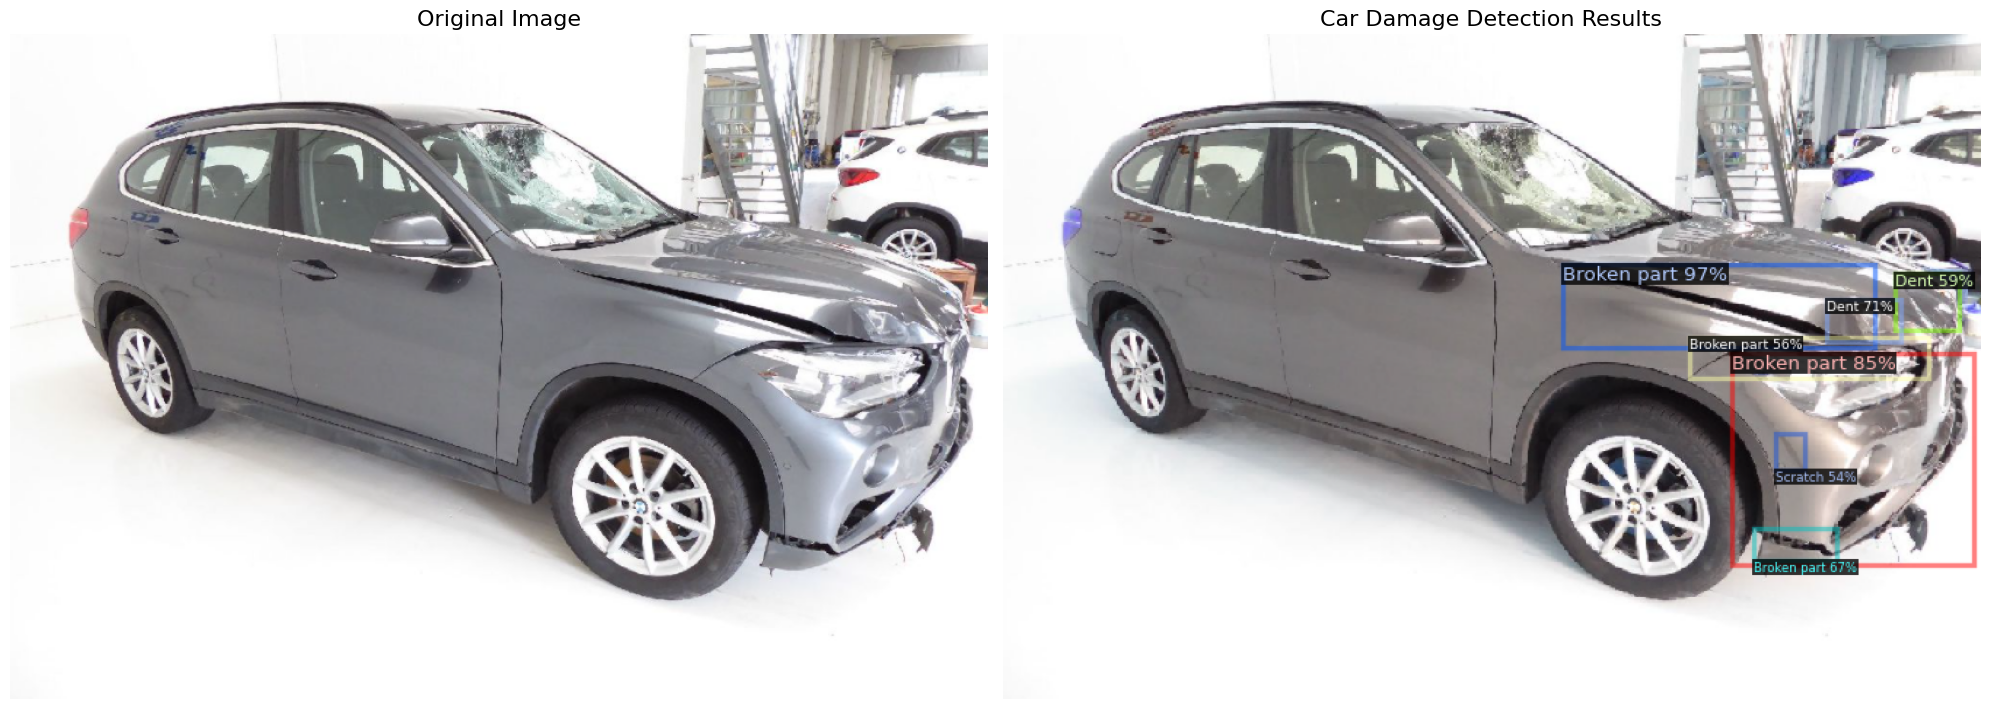


Detected 13 damage(s):
  1. Broken part (confidence: 0.97)
  2. Broken part (confidence: 0.85)
  3. Dent (confidence: 0.71)
  4. Broken part (confidence: 0.67)
  5. Broken part (confidence: 0.64)
  6. Broken part (confidence: 0.62)
  7. Dent (confidence: 0.61)
  8. Dent (confidence: 0.59)
  9. Dent (confidence: 0.59)
  10. Broken part (confidence: 0.56)
  11. Scratch (confidence: 0.54)
  12. Broken part (confidence: 0.52)
  13. Broken part (confidence: 0.51)


In [11]:
# Example: Run inference on a single image
# Replace this path with your own image path
image_path = "../archive/Car damages dataset/File1/img/Car damages 1727.png"

display_predictions(image_path, predictor, cfg, apply_nms_filter=True, nms_threshold=0.1)